# GRPO Curriculum Results Analysis — Save Plots Version

This updated notebook loads GRPO training/evaluation metrics from the `runs/` folder, plots the training/evaluation curves, and **saves every figure** to:

```text
runs/<RUN_NAME>/analysis_outputs/figures/
```

It also saves flattened CSV files, a short Markdown findings summary, and a zip file:

```text
runs/<RUN_NAME>/analysis_outputs.zip
```

After running all cells, upload either the full `analysis_outputs` folder or the generated `analysis_outputs.zip` so the figures can be inserted into the professor report.


In [1]:
import json
import glob
import shutil
import zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    Markdown = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Jupyter display setting
%matplotlib inline


## Configuration

In [2]:
# If this notebook is inside or near formal_rl_length_generalization,
# this tries to find the repository root automatically.
NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for p in [current] + list(current.parents):
        if (p / "runs").exists() or (p / "configs").exists():
            return p
    return current

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)
RUNS_DIR = REPO_ROOT / "runs"

# -------------------------------------------------------------------------
# Choose the run to analyze.
# Change RUN_NAME if your run folder is different.
# If the requested run does not exist, the notebook will fall back to the
# first available GRPO run with train_metrics.json or summary.json.
# -------------------------------------------------------------------------
RUN_NAME = "parity_grpo_curriculum_boundary"
PREFERRED_FALLBACK_RUNS = [
    "parity_grpo_curriculum_boundary",
    "parity_grpo_curriculum_cheap",
    "parity_grpo_from_sft_safe",
    "parity_grpo_from_sft",
    "smoke_log_grpo",
]

available_runs = sorted([p.name for p in RUNS_DIR.iterdir() if p.is_dir()]) if RUNS_DIR.exists() else []

requested = RUNS_DIR / RUN_NAME
if requested.exists():
    RUN_DIR = requested
else:
    fallback = None
    for name in PREFERRED_FALLBACK_RUNS:
        candidate = RUNS_DIR / name
        if candidate.exists() and ((candidate / "train_metrics.json").exists() or (candidate / "summary.json").exists()):
            fallback = candidate
            break
    if fallback is None and RUNS_DIR.exists():
        for candidate in sorted(RUNS_DIR.iterdir()):
            if candidate.is_dir() and ((candidate / "train_metrics.json").exists() or (candidate / "summary.json").exists()):
                fallback = candidate
                break
    RUN_DIR = fallback if fallback is not None else requested
    RUN_NAME = RUN_DIR.name if RUN_DIR is not None else RUN_NAME

OUTPUT_DIR = RUN_DIR / "analysis_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIG_DPI = 200
SAVE_PDF_TOO = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Runs dir:", RUNS_DIR)
print("Available runs:", available_runs)
print("Selected run:", RUN_DIR)
print("Run exists:", RUN_DIR.exists())
print("Figures will be saved to:", FIGURES_DIR)


Repo root: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization
Runs dir: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs
Available runs: ['anbn_grpo_process_terminal', 'parity_grpo_curriculum_boundary', 'parity_grpo_curriculum_cheap', 'parity_grpo_curriculum_cheap_001', 'parity_grpo_curriculum_cheap_002', 'parity_grpo_from_sft', 'parity_grpo_from_sft_safe', 'parity_sft', 'smoke_grpo', 'smoke_log_grpo', 'smoke_log_ppo', 'smoke_log_sft', 'smoke_ppo', 'smoke_sft']
Selected run: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary
Run exists: True
Figures will be saved to: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures


## Figure-saving helper

The helper below saves each matplotlib figure as PNG, and optionally PDF, before displaying it in the notebook.

In [4]:
def safe_name(text: str) -> str:
    """Make a filesystem-safe figure name."""
    allowed = []
    for ch in str(text):
        if ch.isalnum() or ch in {"-", "_"}:
            allowed.append(ch)
        elif ch in {" ", "/", ":", ".", "|", ","}:
            allowed.append("_")
    name = "".join(allowed).strip("_")
    while "__" in name:
        name = name.replace("__", "_")
    return name.lower() or "figure"

saved_figures = []

def save_current_figure(name: str):
    """Save the active matplotlib figure into analysis_outputs/figures."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    base = safe_name(name)
    png_path = FIGURES_DIR / f"{base}.png"
    pdf_path = FIGURES_DIR / f"{base}.pdf"

    fig = plt.gcf()
    fig.tight_layout()
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    saved = [png_path]

    if SAVE_PDF_TOO:
        fig.savefig(pdf_path, bbox_inches="tight")
        saved.append(pdf_path)

    saved_figures.extend(saved)
    print("Saved figure:", png_path)
    return png_path


## SFT baseline

In [5]:
# SFT baseline from your earlier SFT eval output.
# Update this if you rerun SFT and get a new baseline.
SFT_BASELINE = {
    "train_1_40": {
        "process": 0.9683257690431646,
        "terminal": 0.875,
        "exact": 0.775,
    },
    "ood_41_80": {
        "process": 0.5261107668939775,
        "terminal": 0.475,
        "exact": 0.0,
    },
    "ood_81_160": {
        "process": 0.520335488923764,
        "terminal": 0.4625,
        "exact": 0.0,
    },
    "ood_161_320": {
        "process": 0.4987215161762422,
        "terminal": 0.43125,
        "exact": 0.0,
    },
}

pd.DataFrame(SFT_BASELINE).T


,process,terminal,exact
train_1_40,0.968326,0.87500,0.775
ood_41_80,0.526111,0.47500,0.000
ood_81_160,0.520335,0.46250,0.000
ood_161_320,0.498722,0.43125,0.000


## Load metrics

In [6]:
def load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)

def step_from_metric_file(path: Path) -> int:
    return int(path.stem.replace("metrics_step", ""))

metric_files = sorted(RUN_DIR.glob("metrics_step*.json"), key=step_from_metric_file)
train_metrics_path = RUN_DIR / "train_metrics.json"
summary_path = RUN_DIR / "summary.json"

print("Found metric files:", [p.name for p in metric_files])
print("Found train_metrics:", train_metrics_path.exists())
print("Found summary:", summary_path.exists())


Found metric files: ['metrics_step100.json', 'metrics_step200.json', 'metrics_step300.json', 'metrics_step400.json', 'metrics_step500.json']
Found train_metrics: True
Found summary: True


In [7]:
# Dense training logs from train_metrics.json
if train_metrics_path.exists():
    train_history = load_json(train_metrics_path)
    train_df = pd.DataFrame([
        {"step": rec.get("step", i), "algorithm": rec.get("algorithm"), **rec.get("train", {})}
        for i, rec in enumerate(train_history)
    ])
else:
    train_df = pd.DataFrame()

# Fallback: if only summary.json exists, create a one-row training snapshot.
if train_df.empty and summary_path.exists():
    summary = load_json(summary_path)
    final_train = summary.get("final_train_metrics", {})
    if final_train:
        train_df = pd.DataFrame([{ "step": 0, "algorithm": RUN_NAME, **final_train }])

# Eval snapshots from metrics_step*.json
eval_rows = []
snapshot_train_rows = []

for path in metric_files:
    d = load_json(path)
    step = d.get("step", step_from_metric_file(path))

    if "train" in d:
        snapshot_train_rows.append({"step": step, **d["train"]})

    for bucket, vals in d.get("eval", {}).items():
        for metric, value in vals.items():
            eval_rows.append({
                "step": step,
                "bucket": bucket,
                "metric": metric,
                "value": value,
            })

eval_df = pd.DataFrame(eval_rows)
snapshot_train_df = pd.DataFrame(snapshot_train_rows)

print("train_df shape:", train_df.shape)
print("eval_df shape:", eval_df.shape)
print("snapshot_train_df shape:", snapshot_train_df.shape)

display(train_df.head())
display(eval_df.head())

if eval_df.empty:
    print("No metrics_step*.json eval snapshots were found for this run. Training plots will still be saved; evaluation plots need evaluation JSON files.")


train_df shape: (20, 23)
eval_df shape: (30, 4)
snapshot_train_df shape: (5, 22)


,step,algorithm,loss,policy_loss,entropy,reward,rollout_count,generated_tokens_mean,cot_tokens_mean,cot_tokens_total,cot_match_accuracy,cot_match_percent,process_match_accuracy,process_match_percent,output_match_accuracy,output_match_percent,exact_match_accuracy,exact_match_percent,curriculum_stage,train_min_len,train_max_len,generation_max_new_tokens,generation_temperature
0,25,grpo_process_terminal,-0.000000,-0.000000,0.027814,3.000000,8.0,9.5,7.5,60.0,1.000000,100.000000,1.000000,100.000000,1.0,100.0,1.0,100.0,1.0,1.0,40.0,64.0,0.25
1,50,grpo_process_terminal,-0.000000,-0.000000,0.052318,2.921052,8.0,35.5,33.5,268.0,0.960526,96.052632,0.960526,96.052632,1.0,100.0,0.5,50.0,1.0,1.0,40.0,64.0,0.25
2,75,grpo_process_terminal,-0.000000,-0.000000,0.089233,2.194444,8.0,38.0,36.0,288.0,0.847222,84.722222,0.847222,84.722222,0.5,50.0,0.0,0.0,1.0,1.0,40.0,64.0,0.25
3,100,grpo_process_terminal,-0.000000,-0.000000,0.035880,3.000000,8.0,23.0,21.0,168.0,1.000000,100.000000,1.000000,100.000000,1.0,100.0,1.0,100.0,1.0,1.0,40.0,64.0,0.25
4,125,grpo_process_terminal,0.012949,0.012949,0.097595,1.524892,8.0,39.0,37.0,296.0,0.762446,76.244589,0.762446,76.244589,0.0,0.0,0.0,0.0,2.0,35.0,44.0,56.0,0.25


,step,bucket,metric,value
0,100,train_1_40,process,0.979088
1,100,train_1_40,terminal,0.900000
2,100,train_1_40,exact,0.775000
3,100,ood_41_80,process,0.542278
4,100,ood_41_80,terminal,0.475000


## Training rollout plots

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\01_grpo_rollout_reward_accuracy.png


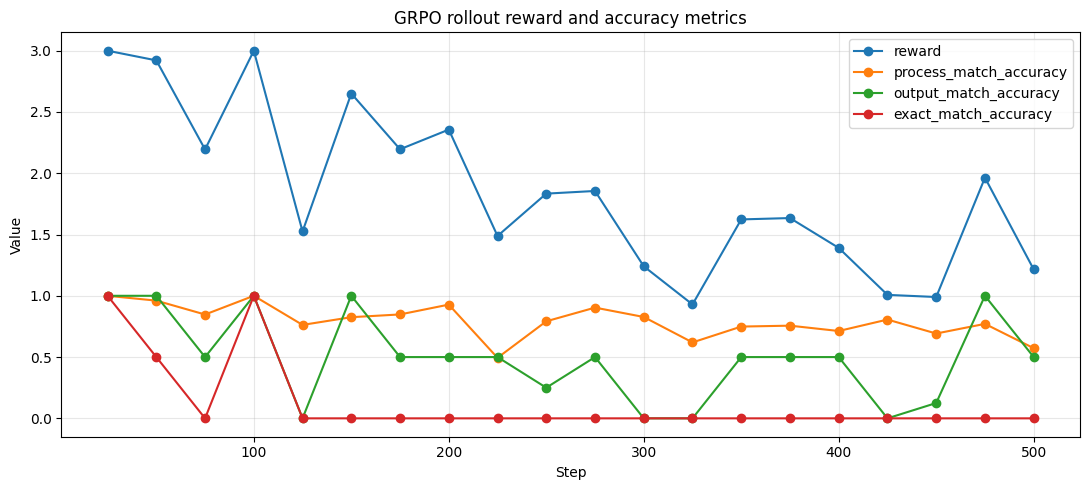

WindowsPath('C:/Users/ravir/CWRU/NLP/projects/Chomskey/formal_rl_length_generalization/runs/parity_grpo_curriculum_boundary/analysis_outputs/figures/01_grpo_rollout_reward_accuracy.png')

In [8]:
def plot_training_metrics(df, metrics, title, ylabel="Value", filename=None):
    if df.empty:
        print("No training metrics found.")
        return None

    plotted = False
    plt.figure(figsize=(11, 5))
    for m in metrics:
        if m in df.columns:
            plt.plot(df["step"], df[m], marker="o", label=m)
            plotted = True

    if not plotted:
        print("None of these metrics were found:", metrics)
        plt.close()
        return None

    plt.xlabel("Step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    path = save_current_figure(filename or title)
    plt.show()
    plt.close()
    return path

plot_training_metrics(
    train_df,
    ["reward", "process_match_accuracy", "output_match_accuracy", "exact_match_accuracy"],
    "GRPO rollout reward and accuracy metrics",
    filename="01_grpo_rollout_reward_accuracy"
)


Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\02_grpo_loss_entropy.png


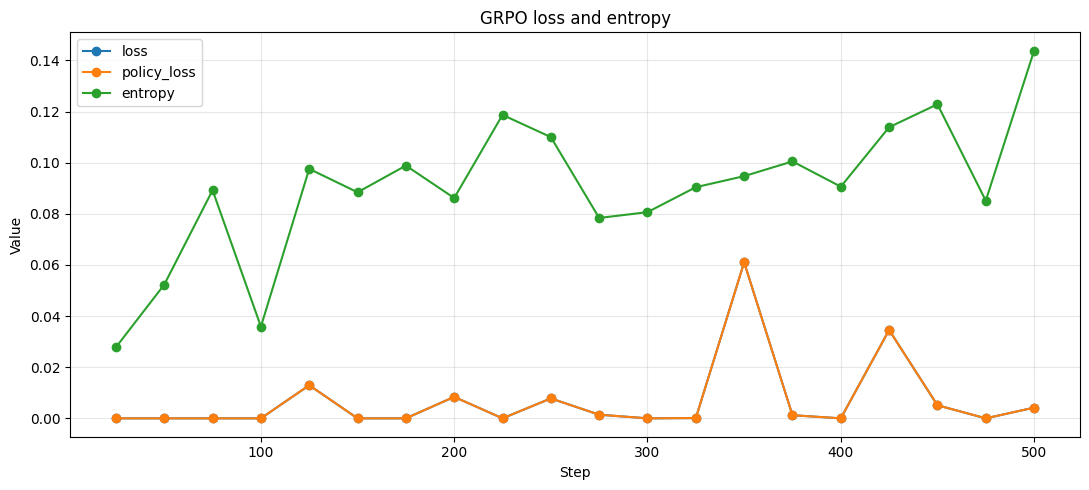

WindowsPath('C:/Users/ravir/CWRU/NLP/projects/Chomskey/formal_rl_length_generalization/runs/parity_grpo_curriculum_boundary/analysis_outputs/figures/02_grpo_loss_entropy.png')

In [9]:
plot_training_metrics(
    train_df,
    ["loss", "policy_loss", "entropy"],
    "GRPO loss and entropy",
    filename="02_grpo_loss_entropy"
)


Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\03_rollout_generated_and_cot_tokens.png


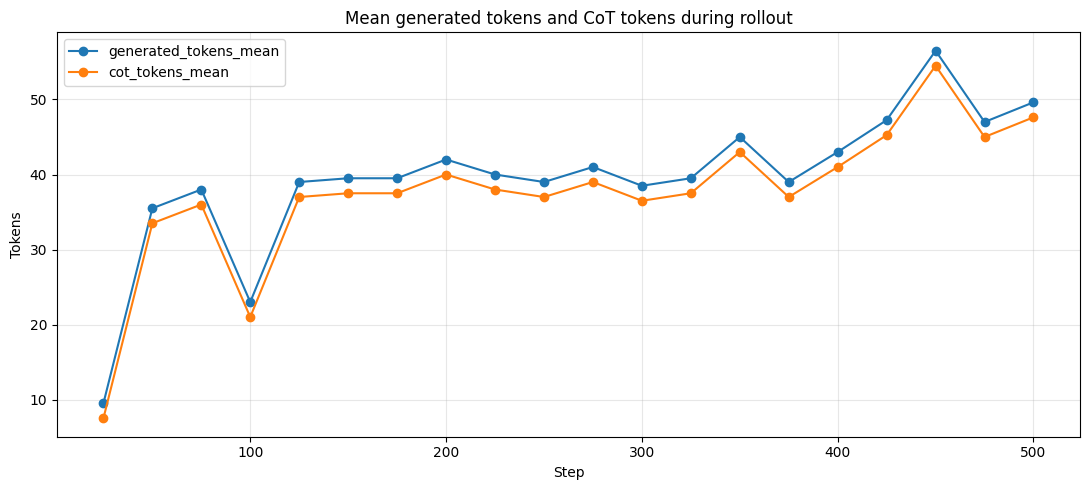

WindowsPath('C:/Users/ravir/CWRU/NLP/projects/Chomskey/formal_rl_length_generalization/runs/parity_grpo_curriculum_boundary/analysis_outputs/figures/03_rollout_generated_and_cot_tokens.png')

In [10]:
plot_training_metrics(
    train_df,
    ["generated_tokens_mean", "cot_tokens_mean"],
    "Mean generated tokens and CoT tokens during rollout",
    ylabel="Tokens",
    filename="03_rollout_generated_and_cot_tokens"
)


Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\04_curriculum_schedule.png


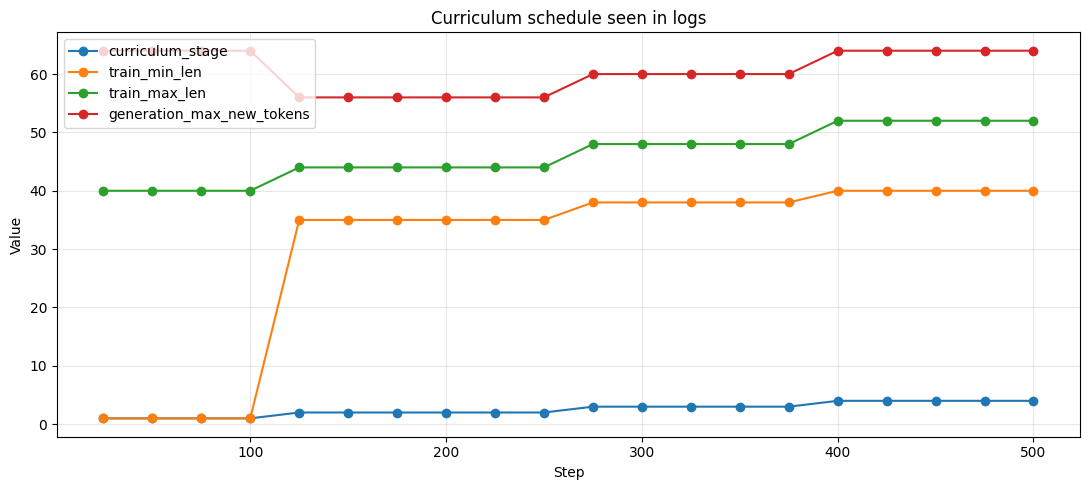

WindowsPath('C:/Users/ravir/CWRU/NLP/projects/Chomskey/formal_rl_length_generalization/runs/parity_grpo_curriculum_boundary/analysis_outputs/figures/04_curriculum_schedule.png')

In [11]:
plot_training_metrics(
    train_df,
    ["curriculum_stage", "train_min_len", "train_max_len", "generation_max_new_tokens"],
    "Curriculum schedule seen in logs",
    filename="04_curriculum_schedule"
)


## Evaluation plots with SFT baseline

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\05_eval_process_by_length_bucket.png


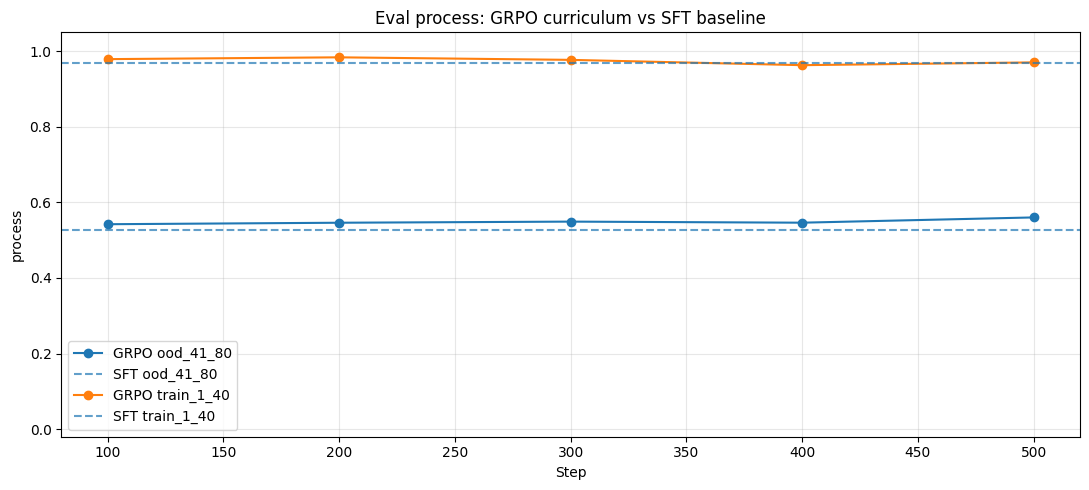

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\05_eval_terminal_by_length_bucket.png


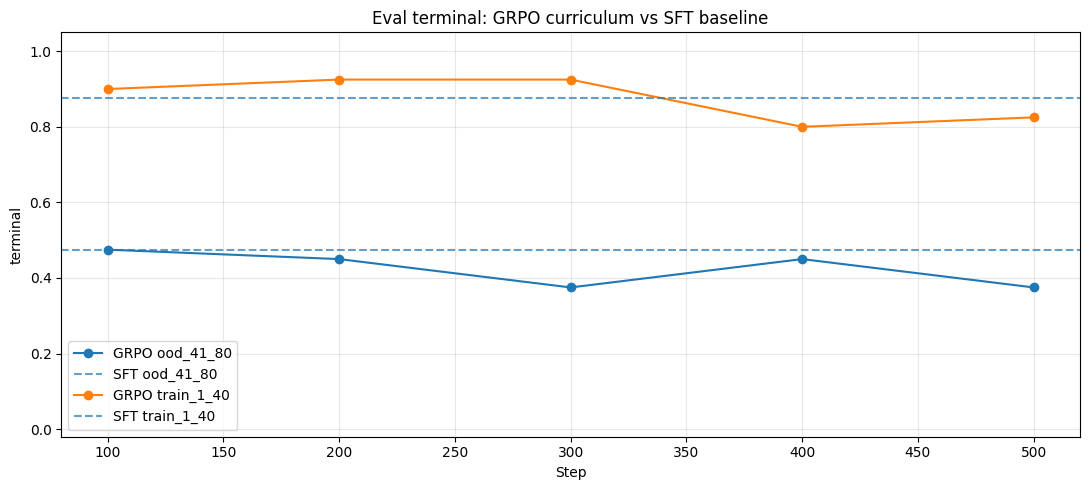

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\05_eval_exact_by_length_bucket.png


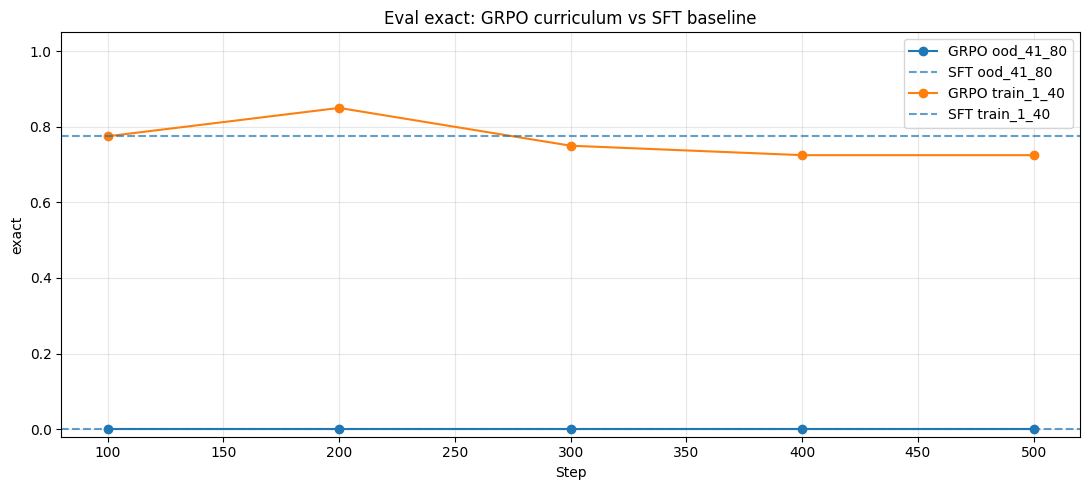

In [12]:
def plot_eval_metric(eval_df, metric, buckets=None, sft_baseline=None, filename=None):
    if eval_df.empty:
        print("No eval metrics found.")
        return None

    data = eval_df[eval_df["metric"] == metric].copy()
    if buckets is not None:
        data = data[data["bucket"].isin(buckets)]

    if data.empty:
        print(f"No eval rows found for metric={metric} and buckets={buckets}")
        return None

    plt.figure(figsize=(11, 5))
    for bucket, g in data.groupby("bucket"):
        g = g.sort_values("step")
        plt.plot(g["step"], g["value"], marker="o", label=f"GRPO {bucket}")

        if sft_baseline and bucket in sft_baseline and metric in sft_baseline[bucket]:
            plt.axhline(
                sft_baseline[bucket][metric],
                linestyle="--",
                alpha=0.7,
                label=f"SFT {bucket}"
            )

    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(f"Eval {metric}: GRPO curriculum vs SFT baseline")
    plt.ylim(-0.02, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    path = save_current_figure(filename or f"eval_{metric}")
    plt.show()
    plt.close()
    return path

# Use the standard length buckets if present.
standard_bucket_order = ["train_1_40", "ood_41_80", "ood_81_160", "ood_161_320", "ood_321_500"]
if not eval_df.empty:
    available_buckets = list(eval_df["bucket"].drop_duplicates())
    buckets_to_plot = [b for b in standard_bucket_order if b in available_buckets]
    if not buckets_to_plot:
        buckets_to_plot = available_buckets
else:
    buckets_to_plot = []

for metric in ["process", "terminal", "exact"]:
    plot_eval_metric(
        eval_df,
        metric,
        buckets=buckets_to_plot,
        sft_baseline=SFT_BASELINE,
        filename=f"05_eval_{metric}_by_length_bucket"
    )


## Final GRPO checkpoint vs SFT

In [13]:
def final_comparison(eval_df, sft_baseline):
    if eval_df.empty or not {"step", "bucket", "metric", "value"}.issubset(eval_df.columns):
        return pd.DataFrame(columns=["bucket", "metric", "sft", "grpo_final", "delta_grpo_minus_sft"])

    final_step = int(eval_df["step"].max())
    final_eval = eval_df[eval_df["step"] == final_step]

    rows = []
    for bucket in sorted(final_eval["bucket"].unique()):
        for metric in ["process", "terminal", "exact"]:
            vals = final_eval[(final_eval["bucket"] == bucket) & (final_eval["metric"] == metric)]["value"]
            if vals.empty:
                continue
            grpo_value = float(vals.iloc[0])
            sft_value = sft_baseline.get(bucket, {}).get(metric)
            rows.append({
                "bucket": bucket,
                "metric": metric,
                "sft": sft_value,
                "grpo_final": grpo_value,
                "delta_grpo_minus_sft": None if sft_value is None else grpo_value - sft_value,
            })
    return pd.DataFrame(rows, columns=["bucket", "metric", "sft", "grpo_final", "delta_grpo_minus_sft"])

comparison_df = final_comparison(eval_df, SFT_BASELINE)
display(comparison_df)

if not comparison_df.empty:
    display(comparison_df.pivot(index="bucket", columns="metric", values=["sft", "grpo_final", "delta_grpo_minus_sft"]))
else:
    print("No final comparison table created because no evaluation snapshots were found.")


,bucket,metric,sft,grpo_final,delta_grpo_minus_sft
0,ood_41_80,process,0.526111,0.560253,0.034142
1,ood_41_80,terminal,0.475000,0.375000,-0.100000
2,ood_41_80,exact,0.000000,0.000000,0.000000
3,train_1_40,process,0.968326,0.970457,0.002132
4,train_1_40,terminal,0.875000,0.825000,-0.050000
5,train_1_40,exact,0.775000,0.725000,-0.050000


sft                    grpo_final                    delta_grpo_minus_sft                   
metric      exact   process terminal      exact   process terminal                exact   process terminal
bucket                                                                                                    
ood_41_80   0.000  0.526111    0.475      0.000  0.560253    0.375                 0.00  0.034142    -0.10
train_1_40  0.775  0.968326    0.875      0.725  0.970457    0.825                -0.05  0.002132    -0.05

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\06_final_sft_vs_grpo_process.png


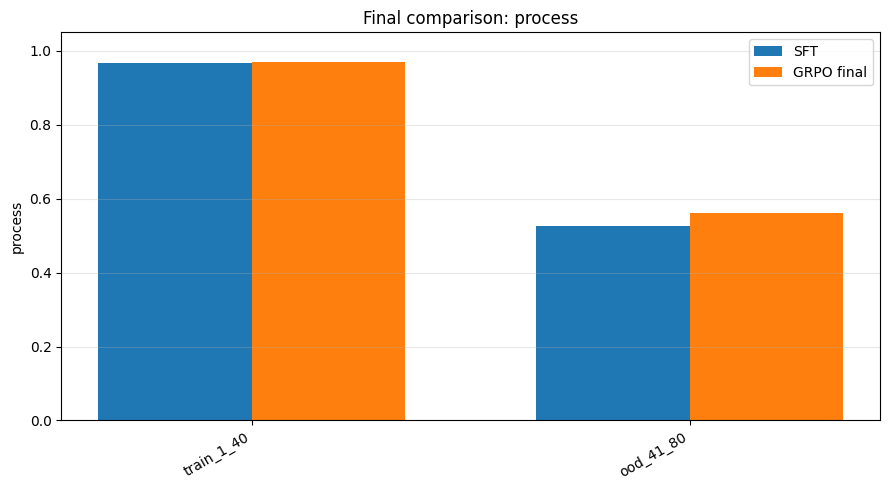

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\06_final_sft_vs_grpo_terminal.png


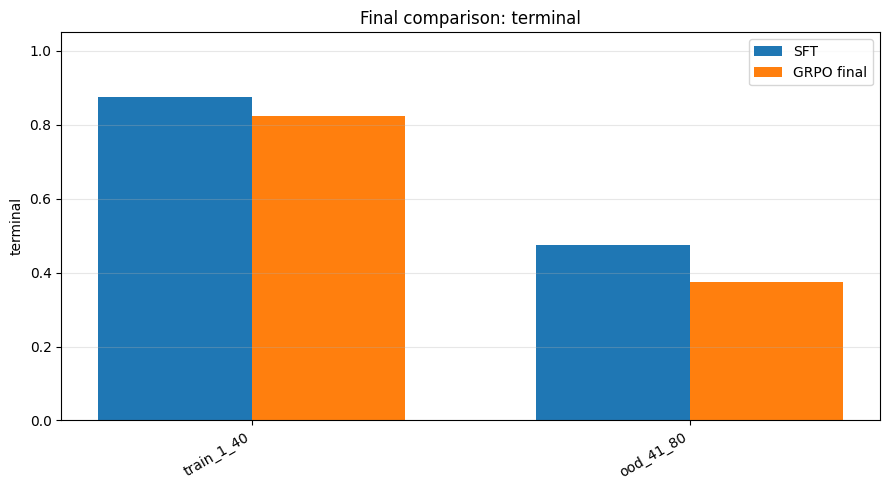

Saved figure: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures\06_final_sft_vs_grpo_exact.png


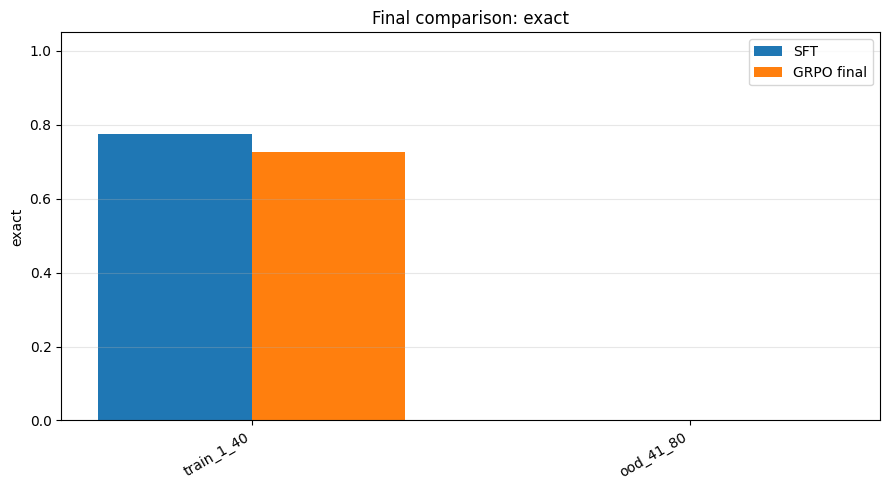

In [14]:
def plot_final_comparison(comparison_df, metric):
    df = comparison_df[comparison_df["metric"] == metric].dropna(subset=["sft"]).copy()
    if df.empty:
        print(f"No data for {metric}")
        return None

    # Keep buckets in the normal length order when possible.
    bucket_order = ["train_1_40", "ood_41_80", "ood_81_160", "ood_161_320", "ood_321_500"]
    df["bucket_order"] = df["bucket"].apply(lambda b: bucket_order.index(b) if b in bucket_order else 999)
    df = df.sort_values(["bucket_order", "bucket"])

    x = range(len(df))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar([i - width / 2 for i in x], df["sft"], width=width, label="SFT")
    plt.bar([i + width / 2 for i in x], df["grpo_final"], width=width, label="GRPO final")
    plt.xticks(list(x), df["bucket"], rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"Final comparison: {metric}")
    plt.ylim(0, 1.05)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    path = save_current_figure(f"06_final_sft_vs_grpo_{metric}")
    plt.show()
    plt.close()
    return path

for metric in ["process", "terminal", "exact"]:
    plot_final_comparison(comparison_df, metric)


## Best checkpoint selection

In [15]:
target_bucket = "ood_41_80"

if eval_df.empty or not {"bucket", "metric", "value"}.issubset(eval_df.columns):
    best_by_terminal = pd.DataFrame()
    best_by_process = pd.DataFrame()
    print("No evaluation snapshots found, so best checkpoint selection is skipped.")
else:
    best_by_terminal = eval_df[(eval_df["bucket"] == target_bucket) & (eval_df["metric"] == "terminal")].sort_values("value", ascending=False)
    best_by_process = eval_df[(eval_df["bucket"] == target_bucket) & (eval_df["metric"] == "process")].sort_values("value", ascending=False)

    print("Best checkpoints by OOD terminal:")
    display(best_by_terminal)

    print("Best checkpoints by OOD process:")
    display(best_by_process)


Best checkpoints by OOD terminal:


,step,bucket,metric,value
4,100,ood_41_80,terminal,0.475
10,200,ood_41_80,terminal,0.450
22,400,ood_41_80,terminal,0.450
16,300,ood_41_80,terminal,0.375
28,500,ood_41_80,terminal,0.375


Best checkpoints by OOD process:


,step,bucket,metric,value
27,500,ood_41_80,process,0.560253
15,300,ood_41_80,process,0.549168
21,400,ood_41_80,process,0.546330
9,200,ood_41_80,process,0.546200
3,100,ood_41_80,process,0.542278


## Save flattened CSVs

In [16]:
out_dir = OUTPUT_DIR
out_dir.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not train_df.empty:
    train_df.to_csv(out_dir / "train_metrics_flat.csv", index=False)
if not eval_df.empty:
    eval_df.to_csv(out_dir / "eval_metrics_long.csv", index=False)
if not comparison_df.empty:
    comparison_df.to_csv(out_dir / "sft_vs_grpo_comparison.csv", index=False)

print("Saved CSV outputs to:", out_dir)
print("Saved figures to:", FIGURES_DIR)


Saved CSV outputs to: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs
Saved figures to: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures


## Save short findings summary and zip outputs

This cell writes a short `analysis_summary.md` and creates `analysis_outputs.zip` beside the run folder. Upload that zip if you want the report to include the plots and numbers exactly from your run.

In [17]:
def make_findings_summary(train_df, eval_df, comparison_df, target_bucket="ood_41_80") -> str:
    lines = []
    lines.append(f"# GRPO Analysis Summary: `{RUN_NAME}`")
    lines.append("")
    lines.append(f"Run directory: `{RUN_DIR}`")
    lines.append(f"Figures directory: `{FIGURES_DIR}`")
    lines.append("")

    if not train_df.empty:
        last = train_df.sort_values("step").iloc[-1]
        lines.append("## Final training rollout snapshot")
        lines.append(f"- Final logged step: {int(last['step'])}")
        for col in ["reward", "process_match_accuracy", "output_match_accuracy", "exact_match_accuracy", "generated_tokens_mean", "cot_tokens_mean"]:
            if col in train_df.columns and pd.notna(last.get(col)):
                val = last[col]
                if isinstance(val, float):
                    lines.append(f"- {col}: {val:.4f}")
                else:
                    lines.append(f"- {col}: {val}")
        lines.append("")

    if not eval_df.empty:
        lines.append("## Best OOD checkpoint selection")
        for metric in ["terminal", "process", "exact"]:
            df = eval_df[(eval_df["bucket"] == target_bucket) & (eval_df["metric"] == metric)].sort_values("value", ascending=False)
            if not df.empty:
                row = df.iloc[0]
                lines.append(f"- Best `{target_bucket}` {metric}: {row['value']:.4f} at step {int(row['step'])}")
        lines.append("")

    if not comparison_df.empty:
        lines.append("## Final GRPO vs SFT comparison")
        compact = comparison_df.copy()
        for _, row in compact.iterrows():
            sft = "n/a" if pd.isna(row.get("sft")) else f"{row['sft']:.4f}"
            grpo = "n/a" if pd.isna(row.get("grpo_final")) else f"{row['grpo_final']:.4f}"
            delta = "n/a" if pd.isna(row.get("delta_grpo_minus_sft")) else f"{row['delta_grpo_minus_sft']:+.4f}"
            lines.append(f"- {row['bucket']} / {row['metric']}: SFT={sft}, GRPO final={grpo}, delta={delta}")
        lines.append("")

    if saved_figures:
        lines.append("## Saved figures")
        for p in saved_figures:
            if str(p).endswith(".png"):
                lines.append(f"- `{p.name}`")
        lines.append("")

    return "\n".join(lines)

summary_text = make_findings_summary(train_df, eval_df, comparison_df)
summary_path = OUTPUT_DIR / "analysis_summary.md"
summary_path.write_text(summary_text)
print("Saved summary:", summary_path)

if Markdown is not None:
    display(Markdown(summary_text))
else:
    print(summary_text)

# Create a zip of the full analysis_outputs folder.
zip_path = RUN_DIR / "analysis_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in OUTPUT_DIR.rglob("*"):
        if path.is_file():
            zf.write(path, arcname=path.relative_to(OUTPUT_DIR.parent))

print("Created zip:", zip_path)
print("Upload this zip after running all cells:", zip_path)


Saved summary: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\analysis_summary.md


# GRPO Analysis Summary: `parity_grpo_curriculum_boundary`

Run directory: `C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary`
Figures directory: `C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs\figures`

## Final training rollout snapshot
- Final logged step: 500
- reward: 1.2156
- process_match_accuracy: 0.5725
- output_match_accuracy: 0.5000
- exact_match_accuracy: 0.0000
- generated_tokens_mean: 49.6250
- cot_tokens_mean: 47.6250

## Best OOD checkpoint selection
- Best `ood_41_80` terminal: 0.4750 at step 100
- Best `ood_41_80` process: 0.5603 at step 500
- Best `ood_41_80` exact: 0.0000 at step 100

## Final GRPO vs SFT comparison
- ood_41_80 / process: SFT=0.5261, GRPO final=0.5603, delta=+0.0341
- ood_41_80 / terminal: SFT=0.4750, GRPO final=0.3750, delta=-0.1000
- ood_41_80 / exact: SFT=0.0000, GRPO final=0.0000, delta=+0.0000
- train_1_40 / process: SFT=0.9683, GRPO final=0.9705, delta=+0.0021
- train_1_40 / terminal: SFT=0.8750, GRPO final=0.8250, delta=-0.0500
- train_1_40 / exact: SFT=0.7750, GRPO final=0.7250, delta=-0.0500

## Saved figures
- `01_grpo_rollout_reward_accuracy.png`
- `02_grpo_loss_entropy.png`
- `03_rollout_generated_and_cot_tokens.png`
- `04_curriculum_schedule.png`
- `05_eval_process_by_length_bucket.png`
- `05_eval_terminal_by_length_bucket.png`
- `05_eval_exact_by_length_bucket.png`
- `06_final_sft_vs_grpo_process.png`
- `06_final_sft_vs_grpo_terminal.png`
- `06_final_sft_vs_grpo_exact.png`


Created zip: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs.zip
Upload this zip after running all cells: C:\Users\ravir\CWRU\NLP\projects\Chomskey\formal_rl_length_generalization\runs\parity_grpo_curriculum_boundary\analysis_outputs.zip
